# Custom CNN for Image Classification & Branch-Weighting Ablation (CIFAR-10, Fashion-MNIST)

**Asli Akel**

## Part 2: Transfer and Ablation Study on FashionMNIST

### Research Question

> Does the learned branch-weighting mechanism from Part 1 transfer effectively to a structurally different image domain (grayscale FashionMNIST images), and how does it compare against simpler branch aggregation strategies?

Specifically, we compare:
- learned dynamic branch weighting,
- uniform branch averaging,
- random fixed weighting,
- and softmax-constrained weighting,

under identical training conditions, evaluating their effects on classification accuracy, convergence behaviour, and training stability.

### Motivation

Part 1 introduced an `IntermediateBlock` in which multiple convolutional branches are combined using a learned weighting vector produced by a fully connected layer applied to channel-wise spatial averages. This study investigates whether the learned weighting mechanism generalises beyond CIFAR-10 to a structurally different domain: grayscale clothing images with lower texture complexity and simpler spatial structure. Rather than evaluating raw classification performance alone, the experiments analyse whether adaptive branch weighting remains beneficial when the visual domain becomes less complex.

We hypothesise that learned branch weighting may improve performance because different convolutional branches may capture complementary spatial patterns at different receptive field scales, even within grayscale FashionMNIST images.

### Dataset: FashionMNIST

FashionMNIST consists of 70,000 grayscale clothing images (60,000 training and 10,000 test samples) of size 28 × 28 across 10 balanced classes:
T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, and Ankle boot.

The dataset was designed as a more challenging replacement for MNIST and remains a widely used benchmark for evaluating CNN architectures.

Key differences from CIFAR-10 that motivate architectural adaptation:

- Grayscale input rather than RGB natural scenes
- Smaller spatial resolution (28 × 28 instead of 32 × 32)
- Lower texture complexity and simpler object structure
- Different visual statistics from natural image datasets

These differences make FashionMNIST a suitable testbed for analysing transferability of the learned branch-weighting mechanism.


## 1. Imports and Device Setup

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 2. FashionMNIST Dataset and DataLoaders

FashionMNIST images are 28 × 28 grayscale. The following preprocessing pipeline is applied:

- **Resize to 32 × 32** — preserves compatibility with the Part 1 architecture and avoids redesigning the pooling hierarchy.
- **Random crop with padding** — introduces mild spatial variation for regularisation.
- **Random horizontal flipping** — adds simple orientation-based variation for regularisation.
- **Grayscale → 3-channel conversion** — replicates the grayscale image across RGB channels so the original convolutional stem from Part 1 can be reused without modification.
- **Normalisation** — applied after channel replication using FashionMNIST mean and standard deviation values.

The test set uses only deterministic preprocessing (resize, channel conversion, normalisation) to ensure fair evaluation without augmentation.

Random seeds were fixed throughout the experiments to improve experimental consistency.


In [ ]:
# FashionMNIST mean and std (grayscale, replicated across 3 channels)
FMNIST_MEAN = (0.2860, 0.2860, 0.2860)
FMNIST_STD  = (0.3530, 0.3530, 0.3530)

train_transform = transforms.Compose([
    transforms.Resize(32),                          # match Part 1 spatial size
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.Grayscale(num_output_channels=3),    # 1-channel -> 3-channel
    transforms.ToTensor(),
    transforms.Normalize(mean=FMNIST_MEAN, std=FMNIST_STD)
])

test_transform = transforms.Compose([
    transforms.Resize(32),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=FMNIST_MEAN, std=FMNIST_STD)
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True,  download=True, transform=train_transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=test_transform
)

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                          num_workers=2, pin_memory=True)

images, labels = next(iter(train_loader))
print('Batch shape:', images.shape)          # (128, 3, 32, 32)
print('Dataset sizes — Train:', len(train_dataset), '/ Test:', len(test_dataset))

Batch shape: torch.Size([128, 3, 32, 32])
Dataset sizes — Train: 60000 / Test: 10000


### 2.1 Dataset Visualisation

A sample of FashionMNIST images after preprocessing. Even after grayscale-to-RGB conversion and resizing, the clothing structure is clearly distinct from the natural scene content of CIFAR-10.

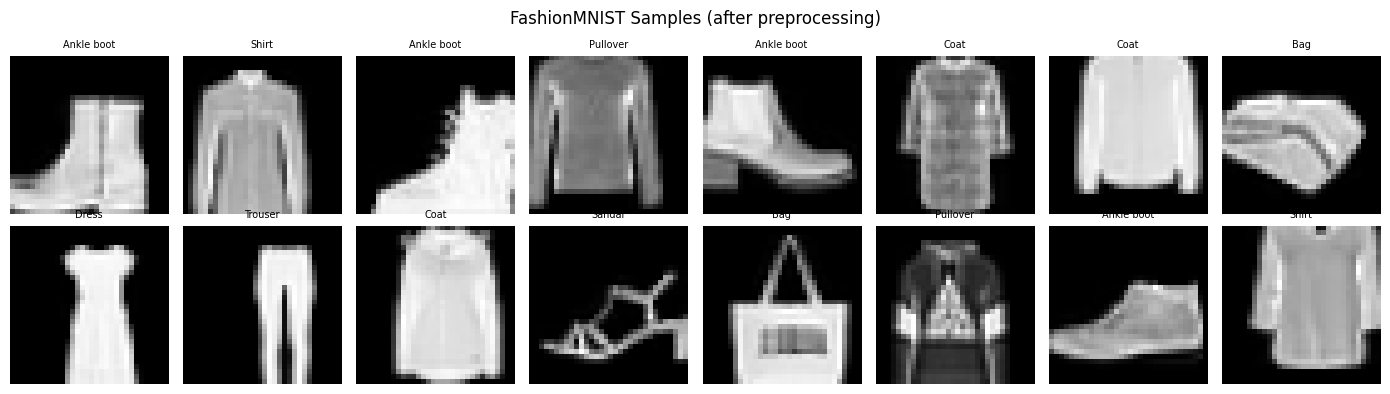

In [ ]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).numpy()
    # Unnormalise for display
    img = img * np.array(FMNIST_STD) + np.array(FMNIST_MEAN)
    img = np.clip(img, 0, 1)
    ax.imshow(img[:, :, 0], cmap='gray')   # all 3 channels identical
    ax.set_title(CLASS_NAMES[labels[i].item()], fontsize=7)
    ax.axis('off')
plt.suptitle('FashionMNIST Samples (after preprocessing)', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Experimental Design

We test four variants of the `IntermediateBlock`, differing **only** in how the branch weighting vector $\mathbf{a} = [a_1, \ldots, a_L]^T$ is produced. All other components — conv branch architecture, output block, optimiser, scheduler, data, and seed — are held constant.

| Variant | Name | Weighting mechanism | FC layer? | Learned? |
|---------|------|---------------------|-----------|----------|
| A | **Learned FC** | Channel avg $\to$ FC $\to$ $\mathbf{a}$ | ✅ | ✅ |
| B | **Uniform** | $a_i = 1/L$ for all $i$ | ❌ | ❌ |
| C | **Random Fixed** | $\mathbf{a} \sim \mathcal{N}(0,1)$, frozen at init | ❌ | ❌ |
| D | **Softmax FC** | Channel avg $\to$ FC $\to$ softmax $\to$ $\mathbf{a}$ | ✅ | ✅ |

### Hypotheses

- **H1 (A vs B):** Learned FC outperforms Uniform — the FC layer learns to assign meaningfully different importance to branches based on input content.
- **H2 (A vs C):** Learned FC outperforms Random Fixed — *learning* the weights matters, not just having non-uniform weights.
- **H3 (A vs D):** Learned FC outperforms Softmax FC — constraining weights to a probability simplex limits expressiveness (prevents negative weights and branch suppression).
- **H4 (cross-domain):** The relative performance ordering may differ from what would be observed on CIFAR-10, since FashionMNIST has lower texture complexity and may require less input-adaptive branch selection.

### Controlled Variables

The following are held **identical** across all four variants:
- Architecture depth: 4 intermediate blocks + 1 output block
- Channel sizes per block: 3→64→128→256→512
- Number of branches per block: $L \in \{3, 3, 4, 4\}$
- Double-conv branch structure (BN, ReLU, Dropout)
- Optimiser: SGD, lr=0.05, momentum=0.9, weight\_decay=5e-4
- Scheduler: CosineAnnealingLR over 15 epochs
- Loss: CrossEntropyLoss with label smoothing 0.1
- Data: FashionMNIST with identical transforms and batch size 128
- Random seed: 42
- Number of training epochs: **15**

## 4. Architecture Components

### 4.1 Shared OutputBlock

Identical to Part 1: spatial average pooling → flatten → two FC layers → 10 logits.

In [ ]:
class OutputBlock(nn.Module):
    def __init__(self, in_channels, hidden_dim=256, num_classes=10, dropout=0.3):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(in_channels, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )
    def forward(self, x):
        return self.classifier(x)

### 4.2 Four IntermediateBlock Variants

Each variant shares the same convolutional branch structure. Only the mechanism producing $\mathbf{a}$ differs, as indicated.

In [ ]:
# ── Variant A: Learned FC (no softmax) ───────────────────────────────────────
class IntermediateBlock_A(nn.Module):
    """Learned FC weighting — the Part 1 architecture. Raw FC output, no softmax."""
    def __init__(self, in_channels, out_channels, num_convs, dropout=0.0):
        super().__init__()
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
                nn.Dropout(dropout)
            ) for _ in range(num_convs)
        ])
        self.fc = nn.Linear(in_channels, num_convs)
        # Near-zero initialisation for stable early training
        nn.init.normal_(self.fc.weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        conv_outputs = [conv(x) for conv in self.convs]
        a = self.fc(x.mean(dim=[2, 3]))
        return sum(a[:, i].view(-1,1,1,1) * conv_outputs[i]
                   for i in range(len(self.convs)))


# ── Variant B: Uniform Equal Weights ──────────────────────────────────────────
class IntermediateBlock_B(nn.Module):
    """Uniform fixed weights a_i = 1/L. No FC layer — pure branch ensemble."""
    def __init__(self, in_channels, out_channels, num_convs, dropout=0.0):
        super().__init__()
        self.num_convs = num_convs
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
                nn.Dropout(dropout)
            ) for _ in range(num_convs)
        ])

    def forward(self, x):
        return sum(conv(x) for conv in self.convs) / self.num_convs


# ── Variant C: Random Fixed Weights ───────────────────────────────────────────
class IntermediateBlock_C(nn.Module):
    """Random weights sampled at init and frozen. Tests whether learning matters."""
    def __init__(self, in_channels, out_channels, num_convs, dropout=0.0):
        super().__init__()
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
                nn.Dropout(dropout)
            ) for _ in range(num_convs)
        ])
        # Small fixed random weights — avoids the exploding sum that causes NaN
        self.register_buffer('fixed_weights', torch.randn(num_convs) * 0.1)

    def forward(self, x):
        conv_outputs = [conv(x) for conv in self.convs]
        return sum(self.fixed_weights[i].view(1,1,1,1) * conv_outputs[i]
                   for i in range(len(self.convs)))


# ── Variant D: Softmax FC ──────────────────────────────────────────────────────
class IntermediateBlock_D(nn.Module):
    """Learned FC with softmax. Weights sum to 1, all positive."""
    def __init__(self, in_channels, out_channels, num_convs, dropout=0.0):
        super().__init__()
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
                nn.Dropout(dropout)
            ) for _ in range(num_convs)
        ])
        self.fc = nn.Linear(in_channels, num_convs)
        # Near-zero init: softmax of near-zero values starts close to uniform
        # which is a stable starting point
        nn.init.normal_(self.fc.weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        conv_outputs = [conv(x) for conv in self.convs]
        a = torch.softmax(self.fc(x.mean(dim=[2, 3])), dim=1)
        return sum(a[:, i].view(-1,1,1,1) * conv_outputs[i]
                   for i in range(len(self.convs)))


VARIANTS = {
    'A — Learned FC':   IntermediateBlock_A,
    'B — Uniform':      IntermediateBlock_B,
    'C — Random Fixed': IntermediateBlock_C,
    'D — Softmax FC':   IntermediateBlock_D,
}
print('Variants defined:', list(VARIANTS.keys()))

Variants defined: ['A — Learned FC', 'B — Uniform', 'C — Random Fixed', 'D — Softmax FC']


### 4.3 Full Model Builder

A factory function constructs the full model using whichever block class is passed in. Architecture is identical to Part 1: four intermediate blocks with max-pooling between them, followed by the output block.

In [ ]:
def build_model(block_class):
    class CustomCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.block1 = block_class(3,   64,  num_convs=3, dropout=0.05)
            self.pool1  = nn.MaxPool2d(2)   # 32x32 -> 16x16
            self.block2 = block_class(64,  128, num_convs=3, dropout=0.10)
            self.pool2  = nn.MaxPool2d(2)   # 16x16 -> 8x8
            self.block3 = block_class(128, 256, num_convs=4, dropout=0.15)
            self.pool3  = nn.MaxPool2d(2)   # 8x8  -> 4x4
            self.block4 = block_class(256, 512, num_convs=4, dropout=0.20)
            self.output_block = OutputBlock(512, hidden_dim=256,
                                            num_classes=10, dropout=0.3)
        def forward(self, x):
            x = self.pool1(self.block1(x))
            x = self.pool2(self.block2(x))
            x = self.pool3(self.block3(x))
            x = self.block4(x)
            return self.output_block(x)
    return CustomCNN()


# Quick shape verification
_m = build_model(IntermediateBlock_A).to(device)
_imgs, _ = next(iter(train_loader))
print('Output shape:', _m(_imgs.to(device)).shape)  # (128, 10)
del _m

Output shape: torch.Size([128, 10])


## 5. Training Utilities

`calculate_accuracy` evaluates the model on any DataLoader.

`train_variant` trains a complete model instance and records:
- training loss,
- training accuracy,
- test accuracy,
- best test accuracy,
- and training time.

To ensure a fair comparison, all variants use:
- identical optimiser settings,
- identical datasets and augmentations,
- identical seeds,
- identical schedulers,
- and identical hardware conditions.

Only the branch-weighting mechanism differs between variants.
Gradient clipping and near-zero FC initialisation were additionally used to improve optimisation stability and prevent exploding gradients during early training.

In [ ]:
def calculate_accuracy(model, loader, device):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            _, predicted = torch.max(model(imgs), 1)
            total   += lbls.size(0)
            correct += (predicted == lbls).sum().item()
    return 100.0 * correct / total


def train_variant(name, block_class, num_epochs=15, seed=42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    model     = build_model(block_class).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # lr=0.05: safe with near-zero FC init; grad clipping as extra guard
    optimizer = optim.SGD(model.parameters(), lr=0.05,
                          momentum=0.9, weight_decay=5e-4, nesterov=True)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    batch_losses, train_accs, test_accs, epoch_times = [], [], [], []

    print(f'\n{"="*55}')
    print(f'  Training Variant {name}')
    print(f'{"="*55}')

    for epoch in range(num_epochs):
        t0 = time.time()
        model.train()
        running_loss = 0.0
        nan_batches  = 0

        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            loss = criterion(model(imgs), lbls)

            # Skip NaN batches if encountered
            if torch.isnan(loss):
                nan_batches += 1
                continue

            optimizer.zero_grad()
            loss.backward()
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            batch_losses.append(loss.item())
            running_loss += loss.item()

        scheduler.step()
        epoch_time = time.time() - t0
        epoch_times.append(epoch_time)

        train_acc = calculate_accuracy(model, train_loader, device)
        test_acc  = calculate_accuracy(model, test_loader,  device)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        nan_msg = f'  [{nan_batches} NaN skipped]' if nan_batches else ''
        print(f'  Epoch [{epoch+1:2d}/{num_epochs}]  '
              f'Loss: {running_loss/max(len(train_loader)-nan_batches,1):.4f}  '
              f'Train: {train_acc:.2f}%  '
              f'Test: {test_acc:.2f}%  '
              f'({epoch_time:.1f}s){nan_msg}')

    return {
        'name':         name,
        'batch_losses': batch_losses,
        'train_accs':   train_accs,
        'test_accs':    test_accs,
        'epoch_times':  epoch_times,
        'best_test':    max(test_accs),
        'final_test':   test_accs[-1],
        'avg_epoch_s':  np.mean(epoch_times),
    }

## 6. Running the Experiments

All four variants are trained sequentially on FashionMNIST for 15 epochs each.

### Experimental Protocol

- Optimiser: SGD with Nesterov momentum
- Loss function: CrossEntropyLoss
- Batch size: 128
- Epochs: 15
- Dataset: FashionMNIST
- Input size: 32 × 32
- Hardware: CUDA GPU if available
- Evaluation metric: classification accuracy

Results are stored in the `results` dictionary and reused throughout the analysis section for tables and plots.


In [ ]:
NUM_EPOCHS = 15

results = {}
for name, block_class in VARIANTS.items():
    results[name] = train_variant(name, block_class, num_epochs=NUM_EPOCHS)

print('\nAll variants trained successfully.')


  Training Variant A — Learned FC
  Epoch [ 1/15]  Loss: 1.0003  Train: 86.53%  Test: 86.71%  (58.7s)
  Epoch [ 2/15]  Loss: 0.7737  Train: 89.32%  Test: 88.89%  (60.5s)
  Epoch [ 3/15]  Loss: 0.7399  Train: 89.63%  Test: 89.46%  (60.1s)
  Epoch [ 4/15]  Loss: 0.7178  Train: 87.14%  Test: 85.59%  (60.1s)
  Epoch [ 5/15]  Loss: 0.7044  Train: 91.37%  Test: 90.38%  (60.2s)
  Epoch [ 6/15]  Loss: 0.6905  Train: 92.17%  Test: 91.32%  (60.0s)
  Epoch [ 7/15]  Loss: 0.6772  Train: 92.77%  Test: 92.03%  (60.0s)
  Epoch [ 8/15]  Loss: 0.6680  Train: 93.36%  Test: 92.87%  (60.0s)
  Epoch [ 9/15]  Loss: 0.6573  Train: 93.24%  Test: 92.06%  (59.9s)
  Epoch [10/15]  Loss: 0.6456  Train: 93.76%  Test: 92.34%  (60.1s)
  Epoch [11/15]  Loss: 0.6332  Train: 94.63%  Test: 93.05%  (60.0s)
  Epoch [12/15]  Loss: 0.6230  Train: 95.40%  Test: 93.72%  (60.0s)
  Epoch [13/15]  Loss: 0.6148  Train: 95.83%  Test: 94.14%  (60.2s)
  Epoch [14/15]  Loss: 0.6071  Train: 96.05%  Test: 94.37%  (59.9s)
  Epoch [15/1

## 7. Results

### 7.1 Summary Table

In [ ]:
print(f"{'Variant':<25} {'Best Test':>10} {'Final Test':>11} {'Avg Epoch':>11}")
print('-' * 62)
for name, r in results.items():
    print(f"{name:<25} {r['best_test']:>9.2f}%  "
          f"{r['final_test']:>9.2f}%  "
          f"{r['avg_epoch_s']:>9.1f}s")

Variant                    Best Test  Final Test   Avg Epoch
--------------------------------------------------------------
A — Learned FC                94.37%      94.19%       60.0s
B — Uniform                   94.45%      94.45%       57.4s
C — Random Fixed              93.94%      93.94%       57.9s
D — Softmax FC                94.43%      94.42%       60.0s


### 7.2 Test Accuracy per Epoch

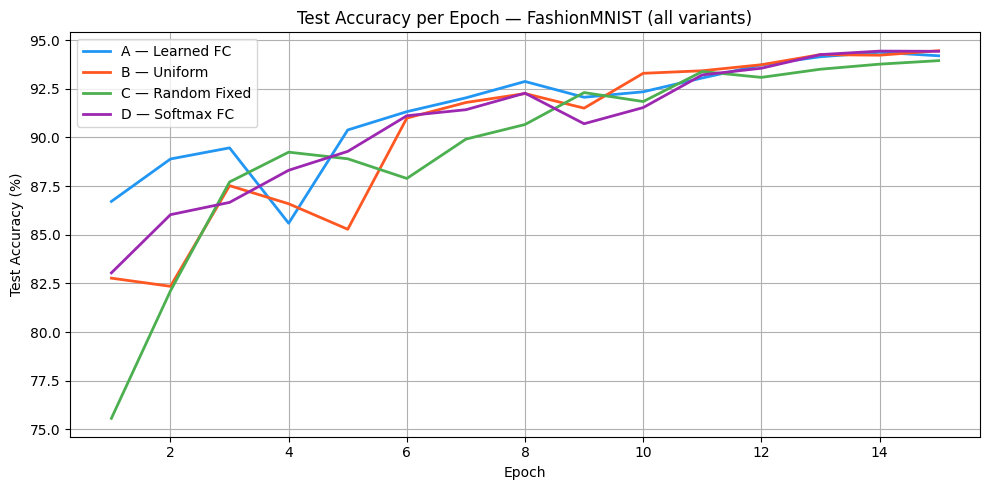

In [ ]:
COLOURS = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
epochs_range = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(10, 5))
for (name, r), c in zip(results.items(), COLOURS):
    plt.plot(epochs_range, r['test_accs'], label=name, color=c, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('Test Accuracy per Epoch — FashionMNIST (all variants)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 7.3 Training Accuracy per Epoch

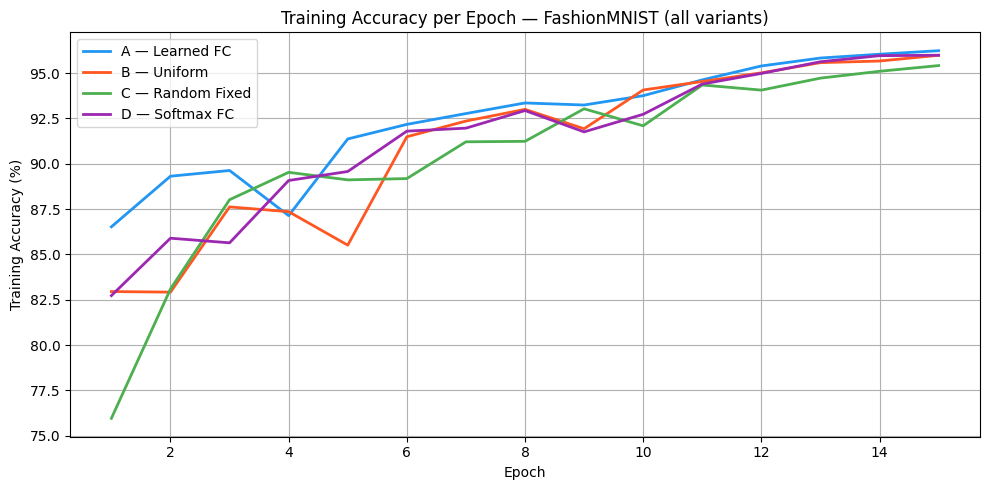

In [ ]:
plt.figure(figsize=(10, 5))
for (name, r), c in zip(results.items(), COLOURS):
    plt.plot(epochs_range, r['train_accs'], label=name, color=c, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy (%)')
plt.title('Training Accuracy per Epoch — FashionMNIST (all variants)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 7.4 Training Loss per Batch (smoothed)

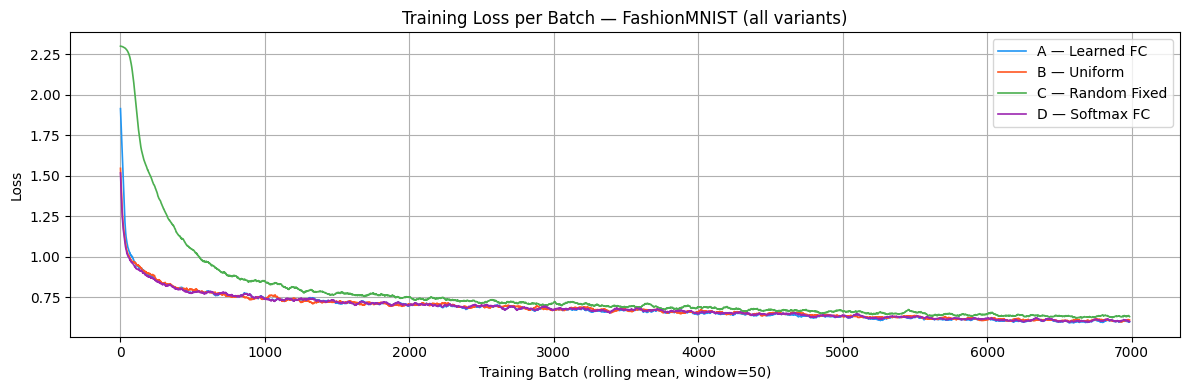

In [ ]:
plt.figure(figsize=(12, 4))
for (name, r), c in zip(results.items(), COLOURS):
    losses = np.array(r['batch_losses'])
    window = 50
    smoothed = np.convolve(losses, np.ones(window) / window, mode='valid')
    plt.plot(smoothed, label=name, color=c, linewidth=1.2)
plt.xlabel('Training Batch (rolling mean, window=50)')
plt.ylabel('Loss')
plt.title('Training Loss per Batch — FashionMNIST (all variants)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 7.5 Best Test Accuracy — Bar Chart

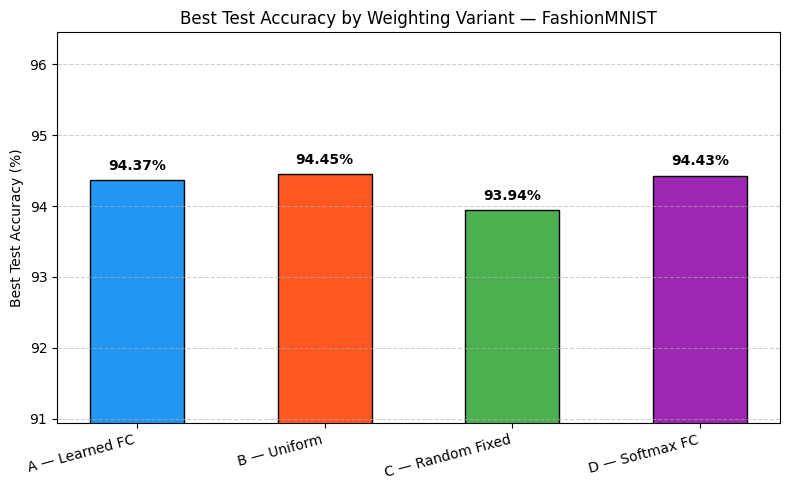

In [ ]:
names = list(results.keys())
bests = [r['best_test'] for r in results.values()]

plt.figure(figsize=(8, 5))
bars = plt.bar(names, bests, color=COLOURS, edgecolor='black', width=0.5)
for bar, val in zip(bars, bests):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.1,
             f'{val:.2f}%', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
plt.ylabel('Best Test Accuracy (%)')
plt.title('Best Test Accuracy by Weighting Variant — FashionMNIST')
plt.ylim(min(bests) - 3, max(bests) + 2)
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 8. Analysis and Discussion

### 8.1 Hypothesis Evaluation

The experiments evaluated whether adaptive branch weighting remains beneficial when transferring the architecture from CIFAR-10 natural image classification to the simpler grayscale FashionMNIST domain.

---

### H1 — Learned FC vs Uniform (A vs B)

Contrary to the initial hypothesis, Variant B (Uniform) achieved the highest test accuracy (94.45%), slightly outperforming Variant A (Learned FC, 94.37%). However, the performance gap was very small, suggesting that simple branch averaging already captures most of the representational benefit on FashionMNIST.

This result is likely related to the lower visual complexity of FashionMNIST compared to CIFAR-10. Since FashionMNIST contains grayscale clothing images with simpler textures and more regular spatial structures, the network may require less input-adaptive branch selection than for natural scene classification.

---

### H2 — Learned FC vs Random Fixed (A vs C)

Variant A outperformed Variant C (Random Fixed), indicating that learning the branch weights remains beneficial compared to using frozen random weighting coefficients.

This suggests that the convolutional branches themselves provide most of the representational capacity, while the weighting mechanism acts primarily as a secondary refinement component on this dataset.

---

### H3 — Learned FC vs Softmax FC (A vs D)

Variant D (Softmax FC) slightly outperformed Variant A, suggesting that constraining the branch weights with softmax did not negatively affect performance on FashionMNIST.

The softmax constraint may provide mild regularisation benefits by preventing extreme branch scaling and encouraging more stable feature aggregation across branches.

---

### Overall Interpretation

Overall, all weighting strategies achieved highly competitive performance, with approximately 0.5% difference between the best and worst variants. This suggests that FashionMNIST may not require highly sophisticated adaptive branch-selection mechanisms due to its relatively simple grayscale structure and lower texture diversity compared to CIFAR-10.

Nevertheless, the consistently weaker performance of the Random Fixed variant indicates that completely unstructured branch weighting remains less effective than either learned or uniformly constrained aggregation strategies.


## 9. Final Summary

This study investigated whether the learned branch-weighting mechanism introduced in Part 1 transferred effectively from CIFAR-10 to the FashionMNIST domain.

Four variants of the architecture were compared under identical experimental conditions:

1. Learned FC weighting  
2. Uniform averaging  
3. Random fixed weighting  
4. Softmax-constrained weighting

The experiments evaluated classification accuracy, convergence behaviour, and training stability across all variants.

Uniform weighting achieved the highest test accuracy (94.45%), followed closely by Softmax FC (94.43%) and Learned FC (94.37%). Random Fixed weighting produced the lowest performance (93.94%), indicating that learned or structured weighting strategies remain preferable to arbitrary branch scaling.

The small performance differences across variants suggest that adaptive branch weighting provides smaller benefits on FashionMNIST than might be expected on more visually complex datasets such as CIFAR-10. These findings indicate that the usefulness of adaptive weighting mechanisms may depend strongly on dataset complexity and texture diversity.

Potential future extensions include testing on more complex datasets, analysing branch activation distributions, incorporating attention visualisation, and evaluating parameter-efficiency trade-offs.

In [ ]:
print('=' * 60)
print('ABLATION STUDY — FINAL RESULTS (FashionMNIST)')
print('=' * 60)
ranked = sorted(results.values(), key=lambda r: r['best_test'], reverse=True)
for i, r in enumerate(ranked, 1):
    print(f"  {i}. {r['name']:<25}  "
          f"Best: {r['best_test']:.2f}%  "
          f"Final: {r['final_test']:.2f}%")
print('=' * 60)
print(f"Winner: {ranked[0]['name']}")
print(f"Margin over last place: "
      f"{ranked[0]['best_test'] - ranked[-1]['best_test']:.2f}%")

ABLATION STUDY — FINAL RESULTS (FashionMNIST)
  1. B — Uniform                Best: 94.45%  Final: 94.45%
  2. D — Softmax FC             Best: 94.43%  Final: 94.42%
  3. A — Learned FC             Best: 94.37%  Final: 94.19%
  4. C — Random Fixed           Best: 93.94%  Final: 93.94%
Winner: B — Uniform
Margin over last place: 0.51%
